In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models

In [ ]:
dataset_path = "/content/drive/MyDrive/Retinopathy"
print(os.listdir(dataset_path))

['export.pkl', 'train.csv', 'Proliferate_DR', 'Severe', 'No_DR', 'Moderate', 'Mild']


In [ ]:
data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    shuffle=True
)

Found 3662 files belonging to 5 classes.


In [ ]:
total_size = len(data)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)

train_data = data.take(train_size)
temp_data = data.skip(train_size)

val_data = temp_data.take(val_size)
test_data = temp_data.skip(val_size)

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

def preprocess(x, y):
    x = tf.cast(x, tf.float32)
    x = data_augmentation(x)
    x = preprocess_input(x)
    return x, y

train_data = train_data.map(preprocess)
val_data = val_data.map(preprocess)
test_data = test_data.map(preprocess)

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Freeze most layers
for layer in base_model.layers[:-25]:
    layer.trainable = False

In [ ]:
x = base_model.output

# Global pooling converts feature maps into vector
x = layers.GlobalAveragePooling2D()(x)

# Dense feature learning layer
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

In [ ]:
#ATTENTION MECHANISM

attention = layers.Dense(512, activation='sigmoid')(x)

# Multiply attention weights with features
x = layers.multiply([x, attention])

In [ ]:

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(5, activation='softmax')(x)  #Output layer


In [ ]:
# BUILD MODEL
model = models.Model(inputs=base_model.input, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,102,760 (19.47 MB)

 Trainable params: 2,514,917 (9.59 MB)

 Non-trainable params: 2,587,843 (9.87 MB)

In [ ]:
# COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# TRAIN MODEL

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=18
)

Epoch 1/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1241s 15s/step - accuracy: 0.6875 - loss: 0.9196 - val_accuracy: 0.7279 - val_loss: 0.7799
Epoch 2/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accuracy: 0.7437 - loss: 0.7293 - val_accuracy: 0.6912 - val_loss: 0.7832
Epoch 3/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 302s 4s/step - accuracy: 0.7633 - loss: 0.6773 - val_accuracy: 0.7518 - val_loss: 0.7158
Epoch 4/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 315s 4s/step - accuracy: 0.7504 - loss: 0.6779 - val_accuracy: 0.7574 - val_loss: 0.6476
Epoch 5/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - accuracy: 0.7734 - loss: 0.6222 - val_accuracy: 0.7702 - val_loss: 0.6524
Epoch 6/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 312s 4s/step - accuracy: 0.7840 - loss: 0.6078 - val_accuracy: 0.7537 - val_loss: 0.6380
Epoch 7/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 300s 4s/step - accuracy: 0.7844 - loss: 0.6084 - val_accuracy: 0.7923 - val_loss: 0.6068
Epoch 8/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 311s 4s/step - accuracy: 0.7902 - loss: 0.5530 - val_accuracy: 0.7960 -

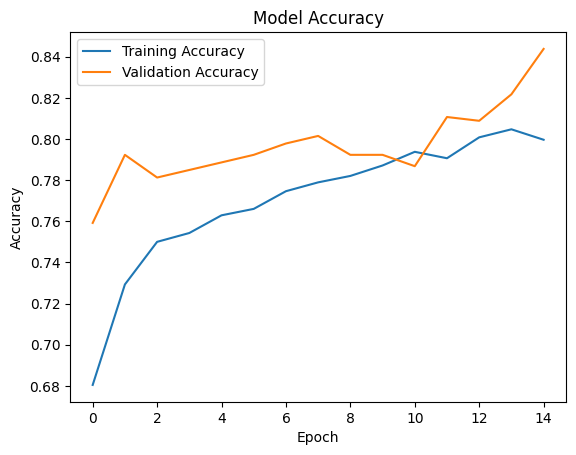

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()


In [ ]:
loss, accuracy = model.evaluate(val_data)
loss, testaccuracy = model.evaluate(test_data)
print("Accuracy:",accuracy)
print("Test Accuracy:", testaccuracy)


17/17 ━━━━━━━━━━━━━━━━━━━━ 24s 727ms/step - accuracy: 0.8235 - loss: 0.5105
18/18 ━━━━━━━━━━━━━━━━━━━━ 122s 6s/step - accuracy: 0.8136 - loss: 0.5160
Accuracy: 0.8235294222831726
Test Accuracy: 0.8136200904846191


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


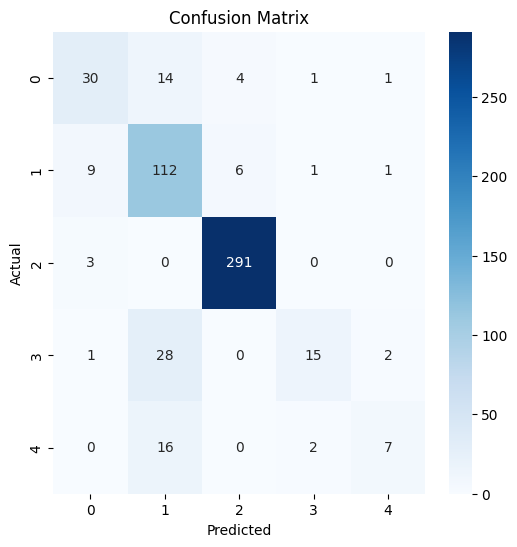

In [ ]:

y_true = []
y_pred = []

for images, labels in val_data:

    preds = model.predict(images)

    preds = np.argmax(preds,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)


cm = confusion_matrix(y_true,y_pred)


plt.figure(figsize=(6,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_true,y_pred))


              precision    recall  f1-score   support

           0       0.70      0.60      0.65        50
           1       0.66      0.87      0.75       129
           2       0.97      0.99      0.98       294
           3       0.79      0.33      0.46        46
           4       0.64      0.28      0.39        25

    accuracy                           0.84       544
   macro avg       0.75      0.61      0.64       544
weighted avg       0.84      0.84      0.82       544



In [ ]:
model.save("DR_detection_model.keras")